## Import Packages and Libraries

In [1]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, auc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os
import time


/opt/homebrew/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Cleaning/Preparation

+ Data cleaning: This involves identifying and correcting errors or inconsistencies in the data, such as missing or duplicate values, incorrect data types, and outliers.

+ Data transformation: This involves transforming the data into a format that is suitable for analysis. This may involve converting data types, standardizing units of measurement, and normalizing or scaling the data.

+ Data integration: This involves combining data from multiple sources into a single dataset. This may involve merging data based on a common key or creating new variables based on existing ones.

+ Feature engineering: This involves creating new variables or features based on the existing data to improve the performance of machine learning algorithms. This may involve creating new variables by combining existing ones or transforming variables to improve their predictive power.

In [2]:
#importing data
covid = pd.read_excel("symptomatic_dataset.xlsx")
covid.head(2)

,ID,Completion_Date,Age,Gender,Banana,Caramel,Mint,Orange,Pineapple,Vanilla,...,6__Alzheimer,7__Cold,8__Cough,9__Fever,10__Muscular_pain,11__Breathing_difficulty,12__Other_COMMENTS,13__Days_with_symptoms,Smoker,COVI19_PCR
0,1,2020-06-01,30,Female,0,0,1,0,1,1,...,0,1,0,0,0,0,anosmia,3,0,1
1,2,2020-06-01,31,Female,0,1,1,1,0,1,...,0,0,1,0,1,0,NaN,2,0,1


In [3]:
start_time = time.time()

In [4]:
covid.columns

Index(['ID', 'Completion_Date', 'Age', 'Gender', 'Banana', 'Caramel', 'Mint',
       'Orange', 'Pineapple', 'Vanilla', '1__Rinitis_or_Sinusitis',
       '2__Respiratory_allergies', '3__Hypertension', '4__Diabetes',
       '5__Parkinson', '6__Alzheimer', '7__Cold', '8__Cough', '9__Fever',
       '10__Muscular_pain', '11__Breathing_difficulty', '12__Other_COMMENTS',
       '13__Days_with_symptoms', 'Smoker', 'COVI19_PCR'],
      dtype='object')

In [5]:
covid.isna().sum()

ID                            0
Completion_Date               0
Age                           0
Gender                        0
Banana                        0
Caramel                       0
Mint                          0
Orange                        0
Pineapple                     0
Vanilla                       0
1__Rinitis_or_Sinusitis       0
2__Respiratory_allergies      0
3__Hypertension               0
4__Diabetes                   0
5__Parkinson                  0
6__Alzheimer                  0
7__Cold                       0
8__Cough                      0
9__Fever                      0
10__Muscular_pain             0
11__Breathing_difficulty      0
12__Other_COMMENTS          660
13__Days_with_symptoms        0
Smoker                        0
COVI19_PCR                    0
dtype: int64

In [6]:
#Create a mask based on the condition
mask = (covid['Banana'] + covid['Caramel'] + covid['Mint'] + covid['Orange'] + covid['Pineapple'] + covid['Vanilla']) > 3

#Assign the values 1 or 0 to the new column based on the mask
covid['Anosmia'] = mask.astype(int)

In [7]:
#drop columns that are not predictors
dropthis = ["ID", "Completion_Date", #"12__Other_COMMENTS",
            "Banana", "Caramel", "Mint", "Orange", "Pineapple", "Vanilla"]
covid_symp = covid.drop(dropthis, axis=1)

### extracting the comments

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

In [9]:
# Create a DataFrame with binary encoding for the presence of each value
binary_comments = covid_symp['12__Other_COMMENTS'].str.get_dummies(sep=',')

In [10]:
#deleting spaces before column names
binary_comments.columns = [col.lstrip() for col in binary_comments.columns]
#checking stats
#binary_comments.sum().sort_values(ascending=False)

In [11]:
binary_comments = binary_comments.sort_index(axis=1)
binary_comments.head(2)

,ageusia,ageusia,allergy,angina,anosmia,anosmia,asma,augesia,bronchitis,chest pain,chest pain,chest pain,clogged nose,cough,depression,depression,dermomiositis,diarrhea,diarrhea,diarrhea anosmia,dizziness,dizziness,dysphagia,dyspnea,dyspnea,ear pain,fatigue,fatigue,fever,fever,fibromyalgia,headache,headache,headache Y diarrhea,headache.,headaches,hiposmia,hipotiridismo,hypothyroidism,indigestion,indigestion,lack of appetite,lack of appetite,lupus,nausea,nausea,nauseas,neumonia,odynophagia,odynophagia,otalgia,pharyngeal itching,rhinorrea,rhinorrhea,shivers,sore throat,sore throat,stomach pain,stomach pain,sweating,vomiting,vomiting nausea
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
binary_comments.columns

Index(['ageusia', 'ageusia', 'allergy', 'angina', 'anosmia', 'anosmia', 'asma',
       'augesia', 'bronchitis', 'chest pain', 'chest pain', 'chest pain',
       'clogged nose', 'cough', 'depression', 'depression', 'dermomiositis',
       'diarrhea', 'diarrhea', 'diarrhea anosmia', 'dizziness', 'dizziness',
       'dysphagia', 'dyspnea', 'dyspnea', 'ear pain', 'fatigue', 'fatigue',
       'fever', 'fever', 'fibromyalgia', 'headache', 'headache',
       'headache Y diarrhea', 'headache.', 'headaches', 'hiposmia',
       'hipotiridismo', 'hypothyroidism', 'indigestion', 'indigestion',
       'lack of appetite', 'lack of appetite', 'lupus', 'nausea', 'nausea',
       'nauseas', 'neumonia', 'odynophagia', 'odynophagia', 'otalgia',
       'pharyngeal itching', 'rhinorrea', 'rhinorrhea', 'shivers',
       'sore throat', 'sore throat', 'stomach pain', 'stomach pain',
       'sweating', 'vomiting', 'vomiting nausea'],
      dtype='object')

headache               112
anosmia                 46
ageusia                 23
odynophagia             19
diarrhea                13
asma                    11
hypothyroidism           8
diarrhea                 7
sore throat              7
fatigue                  4
stomach pain             3
clogged nose             3
augesia                  3
fever                    2
lack of appetite         2
dizziness                2
shivers                  2
nauseas                 1
vomiting nausea         1
vomiting                1
sweating                1
rhinorrhea              1
rhinorrea               1
pharyngeal itching      1
otalgia                 1
neumonia                1
allergy                 1
nausea                  1
angina                  1
bronchitis              1
chest pain              1
chest pain              1
cough                   1
depression              1
depression              1
dermomiositis           1
dizziness               1
dysphagia               1
dyspnea                 1
dyspnea                 1
ear pain                1
fibromyalgia            1
hiposmia                1
hipotiridismo           1
indigestion             1
indigestion             1
lack of appetite        1
lupus                   1
nausea                  1

In [13]:
headache_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'headache' in col_name]
binary_comments['Headache'] = binary_comments.iloc[:, headache_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[headache_cols], axis=1, inplace=True)

In [14]:
headache_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'headache' in col_name]
binary_comments['Headache'].sum()

137

In [15]:
anosmia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'anosmia' in col_name]
binary_comments['Anosmia'] = binary_comments.iloc[:, anosmia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[anosmia_cols], axis=1, inplace=True)

In [16]:
binary_comments['Anosmia'].sum()

58

In [17]:
ageusia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'ageusia' in col_name]
binary_comments['Ageusia'] = binary_comments.iloc[:, ageusia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[ageusia_cols], axis=1, inplace=True)

#augesia                  3
augesia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'augesia' in col_name]
binary_comments['Augesia'] = binary_comments.iloc[:, augesia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[augesia_cols], axis=1, inplace=True)

binary_comments['Ageusia'] = (binary_comments['Ageusia'] + binary_comments['Augesia']).clip(upper=1)

# And then, drop the misspelled column:
binary_comments.drop('Augesia', axis=1, inplace=True)

In [18]:
odynophagia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'odynophagia' in col_name]
binary_comments['Odynophagia'] = binary_comments.iloc[:, odynophagia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[odynophagia_cols], axis=1, inplace=True)

In [19]:
#diarrhea                13
diarrhea_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'diarrhea' in col_name]
binary_comments['Diarrhea'] = binary_comments.iloc[:, diarrhea_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[diarrhea_cols], axis=1, inplace=True)

In [20]:
#asma
asthma_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'asma' in col_name]
binary_comments['Asthma'] = binary_comments.iloc[:, asthma_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[asthma_cols], axis=1, inplace=True)

In [21]:
#hypothyroidism
hypothyroidism_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'hypothyroidism' in col_name]
binary_comments['Hypothyroidism'] = binary_comments.iloc[:, hypothyroidism_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[hypothyroidism_cols], axis=1, inplace=True)

In [22]:
#diarrhea
diarrhea_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'diarrhea' in col_name]
binary_comments['Diarrhea'] = binary_comments.iloc[:, diarrhea_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[diarrhea_cols], axis=1, inplace=True)

In [23]:
#sore throat
sore_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'sore throat' in col_name]
binary_comments['SoreThroat'] = binary_comments.iloc[:, sore_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[sore_cols], axis=1, inplace=True)

In [24]:
#fatigue                  4
fatigue_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'fatigue' in col_name]
binary_comments['Fatigue'] = binary_comments.iloc[:, fatigue_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[fatigue_cols], axis=1, inplace=True)

In [25]:
#stomach pain             3
stomach_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'stomach pain' in col_name]
binary_comments['Stomach'] = binary_comments.iloc[:, stomach_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[stomach_cols], axis=1, inplace=True)

In [26]:
#clogged nose             3
clogged_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'clogged nose' in col_name]
binary_comments['CloggedNose'] = binary_comments.iloc[:, clogged_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[clogged_cols], axis=1, inplace=True)

In [27]:
#fever                    2
fever_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'fever' in col_name]
binary_comments['Fever'] = binary_comments.iloc[:, fever_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[fever_cols], axis=1, inplace=True)

In [28]:
#chest pain                    2
chest_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'chest pain' in col_name]
binary_comments['ChestPain'] = binary_comments.iloc[:, chest_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[chest_cols], axis=1, inplace=True)

In [29]:
#dizziness                   2
dizziness_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'dizziness' in col_name]
binary_comments['Dizziness'] = binary_comments.iloc[:, dizziness_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[dizziness_cols], axis=1, inplace=True)

In [30]:
1
#shivers                   2
shivers_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'shivers' in col_name]
binary_comments['Shivers'] = binary_comments.iloc[:, shivers_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[shivers_cols], axis=1, inplace=True)

In [31]:
#lack of appetite                    2
noAppetite_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'lack of appetite' in col_name]
binary_comments['LossAppetite'] = binary_comments.iloc[:, noAppetite_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[noAppetite_cols], axis=1, inplace=True)

In [32]:
sums = binary_comments.sum()
#Filter columns where the sum is greater than 1
columns_to_keep = sums[sums > 1].index
#Keep only those columns
binary_comments = binary_comments[columns_to_keep]
binary_comments.head()

,Headache,Anosmia,Ageusia,Odynophagia,Asthma,Hypothyroidism,SoreThroat,Fatigue,Stomach,CloggedNose,Fever,ChestPain,Dizziness,Shivers,LossAppetite
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [33]:
sums = binary_comments.sum()
#print(sums)
sorted_cols = sums.sort_values(ascending=False)
sorted_cols

Headache          137
Anosmia            58
Ageusia            29
Odynophagia        29
SoreThroat         12
Asthma             11
Hypothyroidism      8
ChestPain           8
Fatigue             7
Stomach             6
CloggedNose         3
Fever               3
Dizziness           3
LossAppetite        3
Shivers             2
dtype: int64

So we have `binary_comments` as the new df for extra nodes

### re-encoding and renaming columns

In [34]:
#Age ranges
age_groups = {
    range(0, 13): 0, #'0-12',
    range(13, 25): 1, #'13-24',
    range(25, 45): 2, #'25-44',
    range(45, 66): 3, #'45-65',
    range(66, 120): 4, #'66+'
}

gender = {'Female': 0, 'Masculine': 1} 

# encode the age and gender
covid_symp['Age_group'] = covid_symp['Age'].map(lambda Age: next((a for b, a in age_groups.items() if Age in b), None))
covid_symp['Gender'] = covid_symp['Gender'].map(gender)

In [35]:
covid_symp = covid_symp.rename(columns={'1__Rinitis_or_Sinusitis': 'RinitisSinusitis',
                        '2__Respiratory_allergies': 'RespiratoryAllegies',
                        '3__Hypertension': 'Hypertension',
                        '4__Diabetes': 'Diabetes',
                        '5__Parkinson': 'Parkinson',
                        '6__Alzheimer': 'Alzheimer',
                        '7__Cold': 'Cold',
                        '8__Cough': 'Cough',
                        '9__Fever': 'Fever',
                        '10__Muscular_pain': 'MuscularPain',
                        '11__Breathing_difficulty': 'BreatheDiff',
                        '13__Days_with_symptoms': 'SymptomDays'                       
                       })

In [36]:
#checking stats
covid_symp.describe()

,Age,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Parkinson,Alzheimer,Cold,Cough,Fever,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Anosmia,Age_group
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.0,926.0,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,37.293737,0.519438,0.134989,0.139309,0.095032,0.021598,0.0,0.0,0.338013,0.345572,0.168467,0.371490,0.139309,3.098272,0.281857,0.333693,0.830454,2.160907
std,13.073849,0.499892,0.341897,0.346456,0.293418,0.145446,0.0,0.0,0.473289,0.475812,0.374482,0.483464,0.346456,1.421099,0.450147,0.471786,0.375437,0.701369
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,2.000000
50%,35.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,2.000000
75%,46.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.000000,1.000000,0.000000,1.000000,0.000000,5.000000,1.000000,1.000000,1.000000,3.000000
max,84.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,4.000000


In [37]:
#drop Age: age group, Parkinson and Alzheimer has no variance
dropthis = ["Age", "Parkinson", "Alzheimer","12__Other_COMMENTS"]
covid_symp = covid_symp.drop(dropthis, axis=1)

In [38]:
pd.Categorical(covid_symp['Gender']).describe()

,counts,freqs
categories,,
0,445,0.480562
1,481,0.519438


In [39]:
#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target]).columns.tolist()

In [40]:
covid_symp.head()

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,Fever,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Anosmia,Age_group
0,0,0,0,0,0,1,0,0,0,0,3,0,1,0,2
1,0,0,0,0,0,0,1,0,1,0,2,0,1,1,2
2,0,1,0,0,0,1,0,0,1,0,3,0,1,1,2
3,0,0,0,0,0,1,1,1,1,0,2,0,1,0,2
4,1,0,0,0,0,1,1,1,0,0,2,0,1,0,2


In [41]:
covid = pd.merge(covid_symp, binary_comments, how='outer', left_index=True, right_index=True, suffixes=('_initial', '_comment'))

In [42]:
#combining similar columns
for col in covid_symp.columns:
    if col in binary_comments.columns:
        covid[col] = covid[[col + '_initial', col + '_comment']].max(axis=1)

        #drop similar columns
        covid.drop([col + '_initial', col + '_comment'], axis=1, inplace=True)

In [43]:
sums = covid.sum()
columns_to_keep = sums[sums > 1].index
covid = covid[columns_to_keep]

In [44]:
covid.head()

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Age_group,Headache,Ageusia,Odynophagia,Asthma,Hypothyroidism,SoreThroat,Fatigue,Stomach,CloggedNose,ChestPain,Dizziness,Shivers,LossAppetite,Fever,Anosmia
0,0,0,0,0,0,1,0,0,0,3,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,1,1,0,2,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,1,0,1,0,3,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,1,1,1,0,2,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,1,0,0,0,0,1,1,0,0,2,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [45]:
covid.describe()

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Age_group,Headache,Ageusia,Odynophagia,Asthma,Hypothyroidism,SoreThroat,Fatigue,Stomach,CloggedNose,ChestPain,Dizziness,Shivers,LossAppetite,Fever,Anosmia
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,0.519438,0.134989,0.139309,0.095032,0.021598,0.338013,0.345572,0.371490,0.139309,3.098272,0.281857,0.333693,2.160907,0.147948,0.031317,0.031317,0.011879,0.008639,0.012959,0.007559,0.006479,0.003240,0.008639,0.003240,0.002160,0.003240,0.171706,0.862851
std,0.499892,0.341897,0.346456,0.293418,0.145446,0.473289,0.475812,0.483464,0.346456,1.421099,0.450147,0.471786,0.701369,0.355240,0.174268,0.174268,0.108400,0.092596,0.113159,0.086662,0.080277,0.056857,0.092596,0.056857,0.046449,0.056857,0.377329,0.344191
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,5.000000,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [46]:
covid.columns

Index(['Gender', 'RinitisSinusitis', 'RespiratoryAllegies', 'Hypertension',
       'Diabetes', 'Cold', 'Cough', 'MuscularPain', 'BreatheDiff',
       'SymptomDays', 'Smoker', 'COVI19_PCR', 'Age_group', 'Headache',
       'Ageusia', 'Odynophagia', 'Asthma', 'Hypothyroidism', 'SoreThroat',
       'Fatigue', 'Stomach', 'CloggedNose', 'ChestPain', 'Dizziness',
       'Shivers', 'LossAppetite', 'Fever', 'Anosmia'],
      dtype='object')

## Graph the BN Model
Graph the Bayesian Network Model using Daft Package

In [47]:
under = covid[[ 'RespiratoryAllegies', 'Hypertension', 'Diabetes', 'RinitisSinusitis', 'RespiratoryAllegies', 'Asthma', 'Hypothyroidism']].any(axis=1).astype(int)
covid['under_cond'] = under

In [48]:
covid.columns

Index(['Gender', 'RinitisSinusitis', 'RespiratoryAllegies', 'Hypertension',
       'Diabetes', 'Cold', 'Cough', 'MuscularPain', 'BreatheDiff',
       'SymptomDays', 'Smoker', 'COVI19_PCR', 'Age_group', 'Headache',
       'Ageusia', 'Odynophagia', 'Asthma', 'Hypothyroidism', 'SoreThroat',
       'Fatigue', 'Stomach', 'CloggedNose', 'ChestPain', 'Dizziness',
       'Shivers', 'LossAppetite', 'Fever', 'Anosmia', 'under_cond'],
      dtype='object')

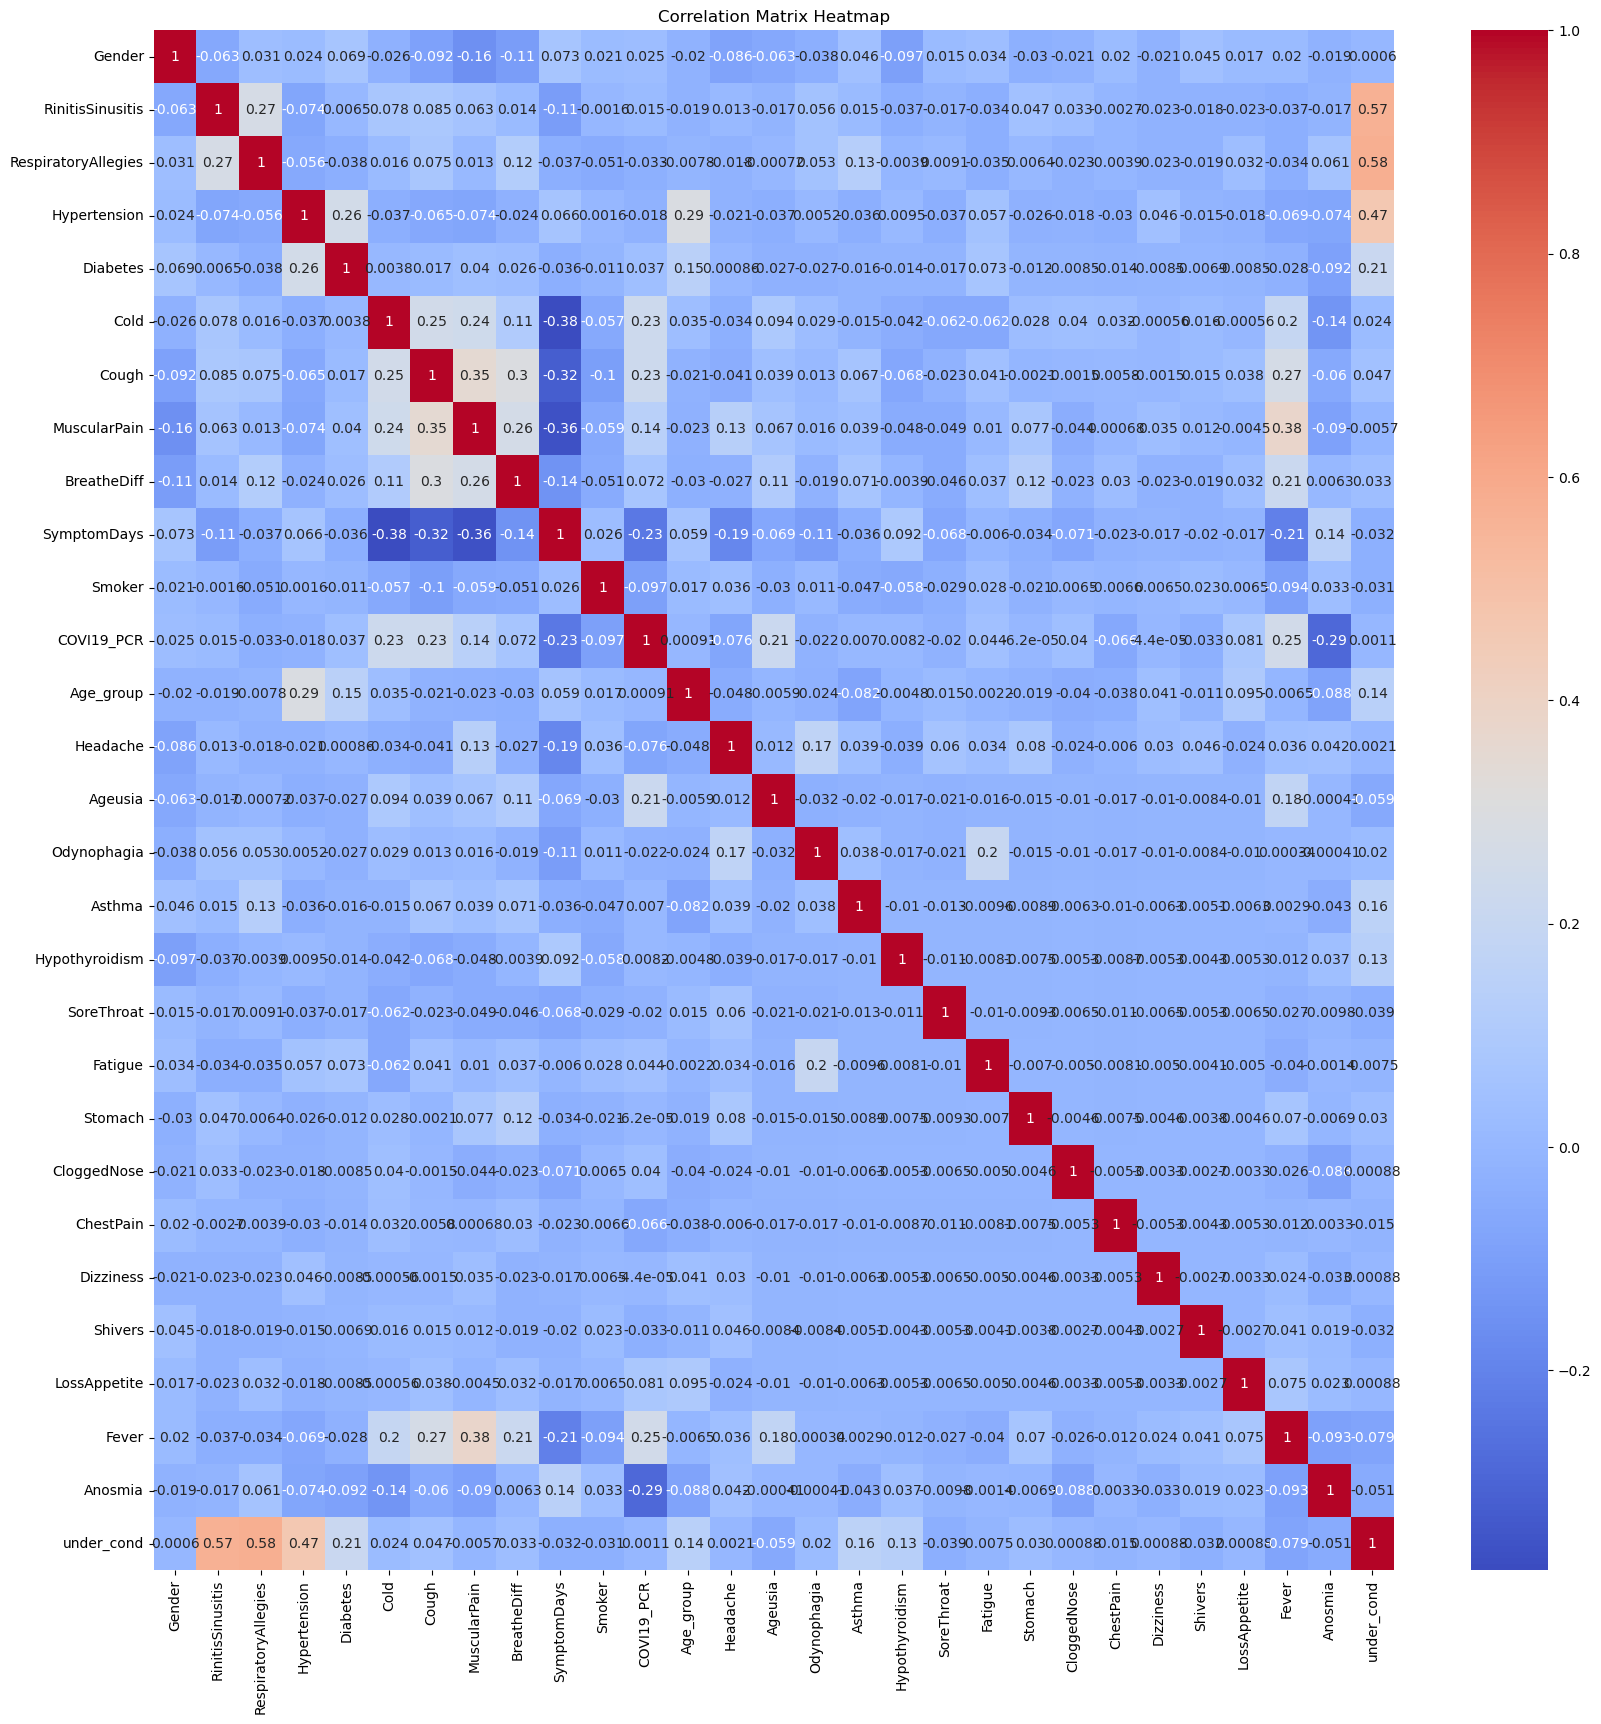

In [49]:
import seaborn as sns
import numpy as np
correlation_matrix = np.corrcoef(covid, rowvar=False)

# Create a heatmap using seaborn
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',xticklabels=covid.columns,
            yticklabels=covid.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [50]:
bnmodel = BayesianNetwork([
    #background (4)
    ('Gender','COVI19_PCR'),('Age_group','COVI19_PCR'),('Smoker','COVI19_PCR'),
    ('under_cond','COVI19_PCR'),('SymptomDays','COVI19_PCR'),
    #symptoms (17)
    ('Cold','COVI19_PCR'),('Cough','COVI19_PCR'),('MuscularPain','COVI19_PCR'),
    ('BreatheDiff','COVI19_PCR'),('Headache','COVI19_PCR'),('Ageusia','COVI19_PCR'),
    ('Odynophagia','COVI19_PCR'),('SoreThroat','COVI19_PCR'),('Fatigue','COVI19_PCR'),
    ('Stomach','COVI19_PCR'),('CloggedNose','COVI19_PCR'),
    ('ChestPain','COVI19_PCR'),('Dizziness','COVI19_PCR'),('Shivers','COVI19_PCR'),
    ('LossAppetite','COVI19_PCR'),('Fever','COVI19_PCR'),('Anosmia','COVI19_PCR'),
    #underlying conditions (6)
    ('RinitisSinusitis','under_cond'),('RespiratoryAllegies','under_cond'),
    ('Hypertension','under_cond'),('Diabetes','under_cond'),('Asthma','under_cond'),
    ('Hypothyroidism','under_cond')
])

In [51]:
covidpgm = PGM(shape=[8,10])
covidpgm.add_node(daft.Node('Gender','Gend',4,10, scale=1.5))
covidpgm.add_node(daft.Node('SymptomDays','Symp\nDays',4,9, scale=1.5))
covidpgm.add_node(daft.Node('Smoker','Smoker',4,8, scale=1.5))
covidpgm.add_node(daft.Node('Age_group','Age\nGroup',4,7, scale=1.5))
covidpgm.add_node(daft.Node('under_cond','Under\nCond',4,6,scale=1.5))
covidpgm.add_node(daft.Node('COVI19_PCR','Covid',2,5, scale=1.5))

covidpgm.add_node(daft.Node('RinitisSinusitis','Rinitis\nSinusitis',6,6,scale=1.5))
covidpgm.add_node(daft.Node('RespiratoryAllegies','Respiratory\nAllergies',6,5,scale=1.5))
covidpgm.add_node(daft.Node('Hypertension','Hyper\ntension',6,4,scale=1.5))
covidpgm.add_node(daft.Node('Diabetes','Diabetes',6,3,scale=1.5))
covidpgm.add_node(daft.Node('Hypothyroidism','Hypothy\nroidism',6,2,scale=1.5))
covidpgm.add_node(daft.Node('Asthma','Asthma',6,1,scale=1.5))

covidpgm.add_node(daft.Node('Cold','Cold',0,1,scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',0,2,scale=1.5))
covidpgm.add_node(daft.Node('MuscularPain','Muscular\nPain',0,3,scale=1.5))
covidpgm.add_node(daft.Node('BreatheDiff','Breathe\nDifficulty',0,4,scale=1.5))
covidpgm.add_node(daft.Node('Headache','Headache',0,5,scale=1.5))
covidpgm.add_node(daft.Node('Ageusia','Ageusia',0,6,scale=1.5))
covidpgm.add_node(daft.Node('Odynophagia','Odyno\nphagia',0,7,scale=1.5))
covidpgm.add_node(daft.Node('SoreThroat','Sore\nThroat',0,8,scale=1.5))
covidpgm.add_node(daft.Node('Fatigue','Fatigue',0,9,scale=1.5))
covidpgm.add_node(daft.Node('Stomach','Stomach',0,10,scale=1.5))
covidpgm.add_node(daft.Node('CloggedNose','Clogged\nNose',1,10,scale=1.5))
covidpgm.add_node(daft.Node('ChestPain','Chest\nPain',2,10,scale=1.5))
covidpgm.add_node(daft.Node('Dizziness','Dizziness',5,1,scale=1.5))
covidpgm.add_node(daft.Node('Shivers','Shivers',1,1,scale=1.5))
covidpgm.add_node(daft.Node('LossAppetite','Loss\nAppetite',2,1,scale=1.5))
covidpgm.add_node(daft.Node('Fever','Fever',3,1,scale=1.5))
covidpgm.add_node(daft.Node('Anosmia','Anosmia',4,1,scale=1.5))

In [52]:
covidpgm.add_edge('Gender','COVI19_PCR')
covidpgm.add_edge('Age_group','COVI19_PCR')
covidpgm.add_edge('Smoker','COVI19_PCR')
covidpgm.add_edge('under_cond','COVI19_PCR')
    #symptoms (18)
covidpgm.add_edge('Cold','COVI19_PCR')
covidpgm.add_edge('Cough','COVI19_PCR')
covidpgm.add_edge('MuscularPain','COVI19_PCR')
covidpgm.add_edge('BreatheDiff','COVI19_PCR')
covidpgm.add_edge('Headache','COVI19_PCR')
covidpgm.add_edge('Ageusia','COVI19_PCR')
covidpgm.add_edge('Odynophagia','COVI19_PCR')
covidpgm.add_edge('SoreThroat','COVI19_PCR')
covidpgm.add_edge('Fatigue','COVI19_PCR')
covidpgm.add_edge('Stomach','COVI19_PCR')
covidpgm.add_edge('CloggedNose','COVI19_PCR')
covidpgm.add_edge('ChestPain','COVI19_PCR')
covidpgm.add_edge('Dizziness','COVI19_PCR')
covidpgm.add_edge('Shivers','COVI19_PCR')
covidpgm.add_edge('LossAppetite','COVI19_PCR')
covidpgm.add_edge('Fever','COVI19_PCR')
covidpgm.add_edge('Anosmia','COVI19_PCR')
    #underlying conditions (6)
covidpgm.add_edge('RinitisSinusitis','under_cond')
covidpgm.add_edge('RespiratoryAllegies','under_cond')
covidpgm.add_edge('Hypertension','under_cond')
covidpgm.add_edge('Diabetes','under_cond')
covidpgm.add_edge('Asthma','under_cond')
covidpgm.add_edge('Hypothyroidism','under_cond')

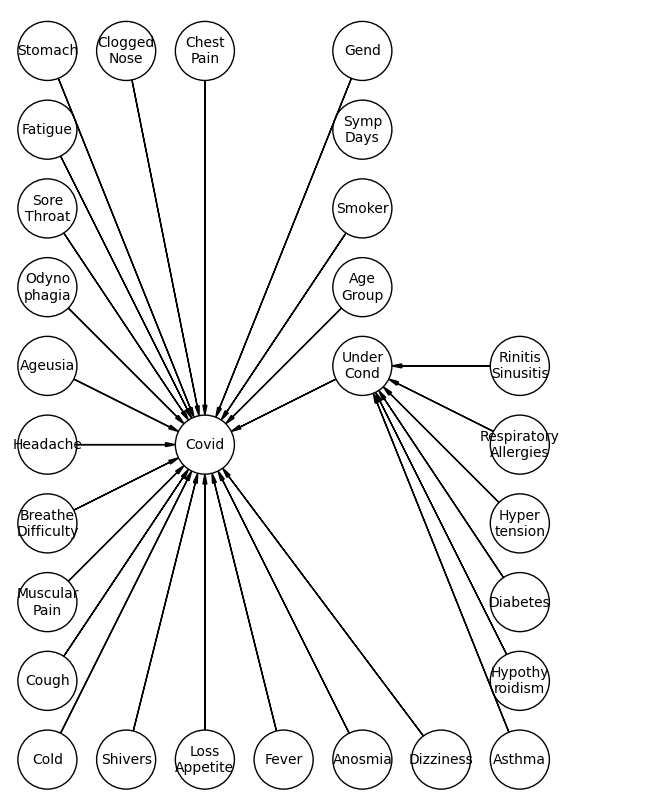

In [53]:
covidpgm.render()
plt.show()

## Prepare the Model in pgmpy
This includes:

+ plugging in CPDs of parent nodes
+ estimating CPDs of the rest of the nodes
+ calculating the likelihood of certain nodes, dependent and independent

<Axes: >

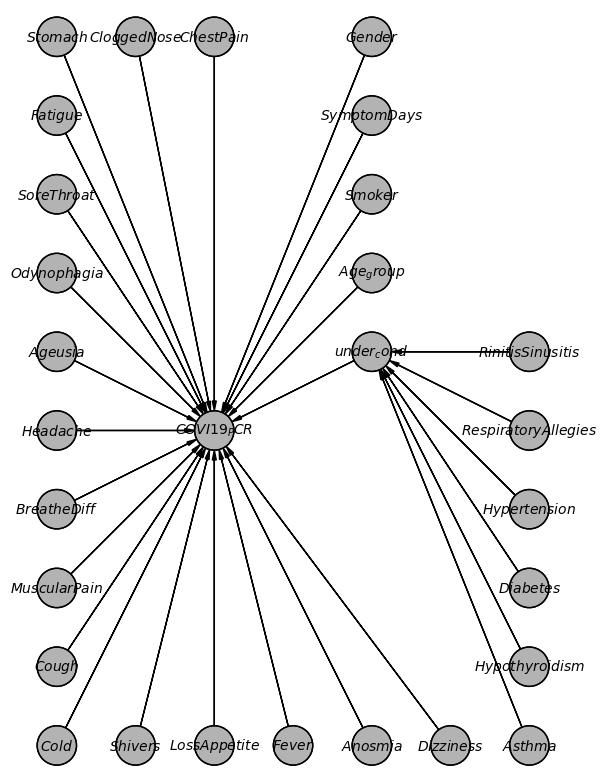

In [54]:
bnmodel.to_daft(node_pos={'Gender':(4,10),
                        'SymptomDays':(4,9),
                        'Smoker':(4,8),
                        'Age_group':(4,7),
                        'under_cond':(4,6),
                        'COVI19_PCR':(2,5),
                        'RinitisSinusitis':(6,6),
                        'RespiratoryAllegies':(6,5),
                        'Hypertension':(6,4),
                        'Diabetes':(6,3),
                        'Hypothyroidism':(6,2),
                        'Asthma':(6,1),
                        'Cold':(0,1),
                        'Cough':(0,2),
                        'MuscularPain':(0,3),
                        'BreatheDiff':(0,4),
                        'Headache':(0,5),
                        'Ageusia':(0,6),
                        'Odynophagia':(0,7),
                        'SoreThroat':(0,8),
                        'Fatigue':(0,9),
                        'Stomach':(0,10),
                        'CloggedNose':(1,10),
                        'ChestPain':(2,10),
                        'Dizziness':(5,1),
                        'Shivers':(1,1),
                        'LossAppetite':(2,1),
                        'Fever':(3,1),
                        'Anosmia':(4,1)
                         }).render()

In [55]:
target = 'COVI19_PCR'
features = covid.drop(columns=[target])
target = covid[target]

In [56]:
Hypercpd = TabularCPD(variable='Hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='Diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='Asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%
ResAlcpd = TabularCPD(variable='RespiratoryAllegies',
                       variable_card=2,
                       values=[[.19], [.81]])
RinSinAlcpd = TabularCPD(variable='RinitisSinusitis',
                       variable_card=2,
                       values=[[.196], [.804]]) #union from AIHW 19.6%
Hypocpd = TabularCPD(variable='Hypothyroidism',
                       variable_card=2,
                       values=[[.046], [.954]])


Gendcpd = TabularCPD(variable='Gender',
                       variable_card=2,
                       values=[[.5021], [.4979]]) #from ABS population
Agecpd = TabularCPD(variable='Age_group', #from ABS 
                       variable_card=5,
                       values=[[.17], [.135], [0.282], [0.242], [0.171]])
Smokecpd = TabularCPD(variable='Smoker',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%

                        
Coldcpd = TabularCPD(variable='Cold',
                       variable_card=2,
                       values=[[.125], [.875]]) #20% on winters
Coughcpd = TabularCPD(variable='Cough',
                       variable_card=2,
                       values=[[.1], [.9]]) #15% on winters
MPcpd = TabularCPD(variable='MuscularPain',
                       variable_card=2,
                       values=[[.15], [.85]])
BDcpd = TabularCPD(variable='BreatheDiff',
                       variable_card=2,
                       values=[[.075], [.925]]) #
Headachecpd = TabularCPD(variable='Headache',
                       variable_card=2,
                       values=[[.15], [.85]])
Anosmiacpd = TabularCPD(variable='Anosmia',
                       variable_card=2,
                       values=[[.03], [.97]])
Ageusiacpd = TabularCPD(variable='Ageusia',
                       variable_card=2,
                       values=[[.02], [.98]])
Odynophagiacpd = TabularCPD(variable='Odynophagia',
                       variable_card=2,
                       values=[[.035], [.965]])
Sorethroatcpd = TabularCPD(variable='SoreThroat',
                       variable_card=2,
                       values=[[.1], [.90]])
Fatiguecpd = TabularCPD(variable='Fatigue',
                       variable_card=2,
                       values=[[.2], [.8]])
Stomachcpd = TabularCPD(variable='Stomach',
                       variable_card=2,
                       values=[[.125], [.875]])
Cloggedcpd = TabularCPD(variable='CloggedNose',
                       variable_card=2,
                       values=[[.1], [.9]])
ChestPaincpd = TabularCPD(variable='ChestPain',
                       variable_card=2,
                       values=[[.075], [.925]])
Dizzcpd = TabularCPD(variable='Dizziness',
                       variable_card=2,
                       values=[[.075], [.925]])
Shiverscpd = TabularCPD(variable='Shivers',
                       variable_card=2,
                       values=[[.06], [.94]])
LossAppcpd = TabularCPD(variable='LossAppetite',
                       variable_card=2,
                       values=[[.1], [.9]])
Fevercpd = TabularCPD(variable='Fever',
                       variable_card=2,
                       values=[[.06], [.94]])

In [57]:
bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,ResAlcpd,RinSinAlcpd,Hypocpd, #6
                 Gendcpd,Agecpd,Smokecpd, #3
                 Coldcpd,Coughcpd,MPcpd,BDcpd,Headachecpd,Anosmiacpd, #6
                 Ageusiacpd,Odynophagiacpd,Sorethroatcpd,Fatiguecpd, #4
                 Stomachcpd,Cloggedcpd,ChestPaincpd,Dizzcpd,Shiverscpd,#5
                 LossAppcpd,Fevercpd) #2

In [58]:
#mle = MaximumLikelihoodEstimator(bnmodel, covid)
#COVIDcpd = mle.estimate_cpd('COVI19_PCR')
#UCcpd = mle.estimate_cpd('under_cond')
#SDayscpd = mle.estimate_cpd('SymptomDays')
covid.shape

(926, 29)

In [59]:
# Split the dataset into train and test sets
training_data, testing_data = train_test_split(covid, test_size=0.2, random_state=42)

# Split the dataset into training and testing sets
X_valid, X_test, y_valid, y_test = train_test_split(testing_data[features.columns], testing_data['COVI19_PCR'], test_size=0.2, random_state=42)

In [60]:
estimator = BayesianEstimator(bnmodel,training_data)

In [61]:
COVIDcpd = estimator.estimate_cpd('COVI19_PCR')
UCcpd = estimator.estimate_cpd('under_cond')
SDayscpd = estimator.estimate_cpd('SymptomDays')

In [62]:
bnmodel.add_cpds(COVIDcpd,UCcpd,SDayscpd)

cpds = bnmodel.get_cpds()
for cpd in cpds:
    print(cpd)

In [63]:
infer=VariableElimination(bnmodel)

In [64]:
evidence = {'Smoker': 0,'Asthma':1, 'Fever': 1, 'Cough':1, 'Anosmia':1,'BreatheDiff':1,'SymptomDays':3} #0 is false
print(infer.query(['COVI19_PCR'], evidence=evidence))

+---------------+-------------------+
| COVI19_PCR    |   phi(COVI19_PCR) |
+===============+===================+
| COVI19_PCR(0) |            0.5000 |
+---------------+-------------------+
| COVI19_PCR(1) |            0.5000 |
+---------------+-------------------+


## Test and Train

In [66]:
features = covid.drop(columns=['COVI19_PCR'])

In [67]:
predictions = []
for i in range(len(X_valid)):
    evidence = X_valid.iloc[i].to_dict()
    query = 'COVI19_PCR'
    factor = infer.query([query], evidence=evidence)
    prediction = factor.values[1]
    predictions.append(prediction)

newpred=[]
for i in range(len(predictions)):
    if predictions[i]>=.870: # start with a threshold of 0.5
        newpred.append(1)
    else:
        newpred.append(0)

In [68]:
# Assuming you ha]ve the true labels and predicted labels
true_labels = y_valid
predicted_labels = newpred

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[95  3]
 [46  4]]


In [69]:
# Extracting the values from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculating accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

Accuracy: 0.668918918918919


[[51 15]
 [22  5]]
Accuracy: 0.6021505376344086


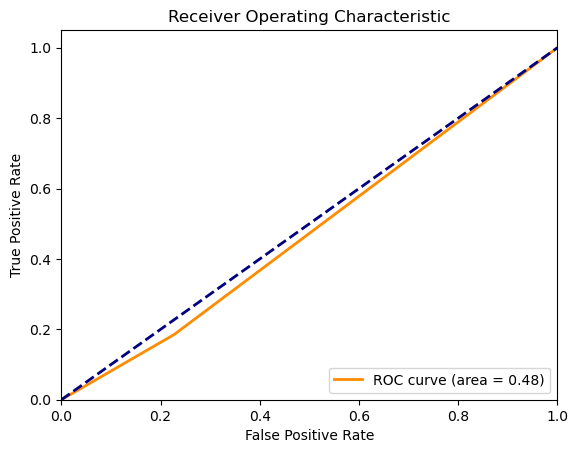

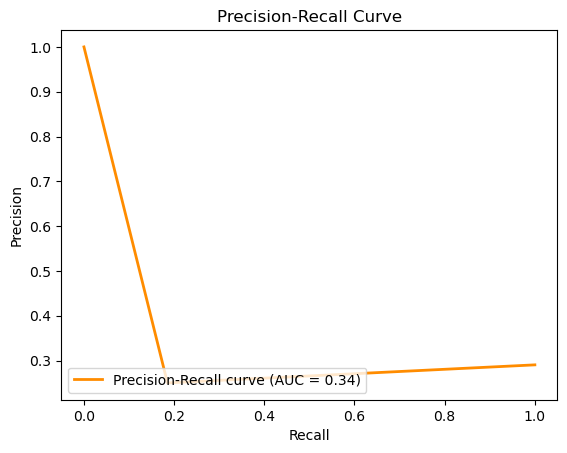

[[52 12]
 [23  6]]
Accuracy: 0.6236559139784946


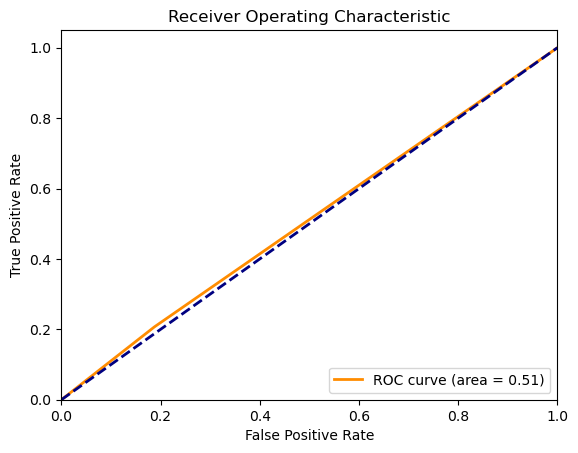

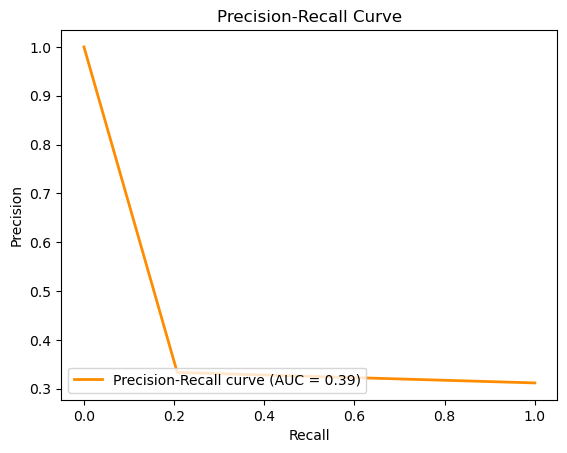

[[44 13]
 [32  4]]
Accuracy: 0.5161290322580645


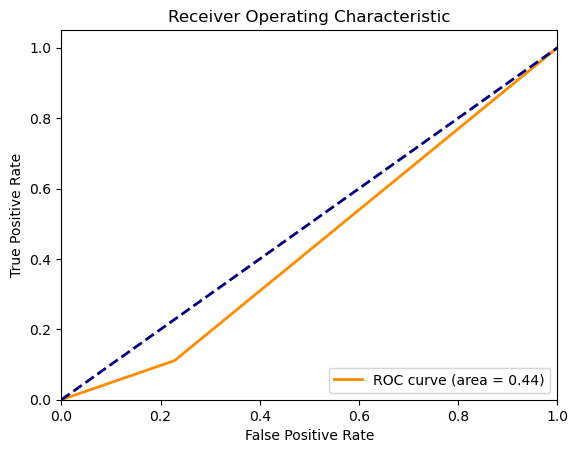

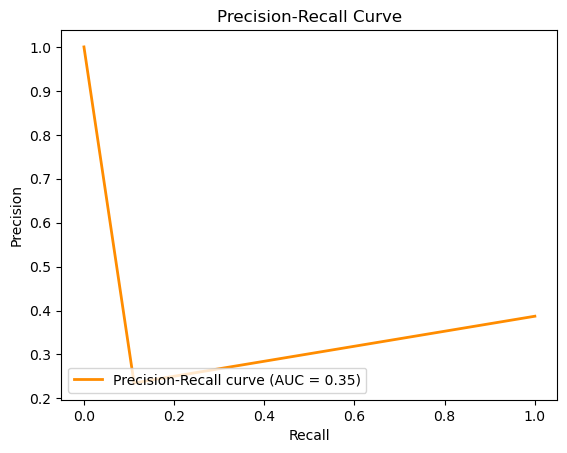

[[55 15]
 [17  6]]
Accuracy: 0.6559139784946236


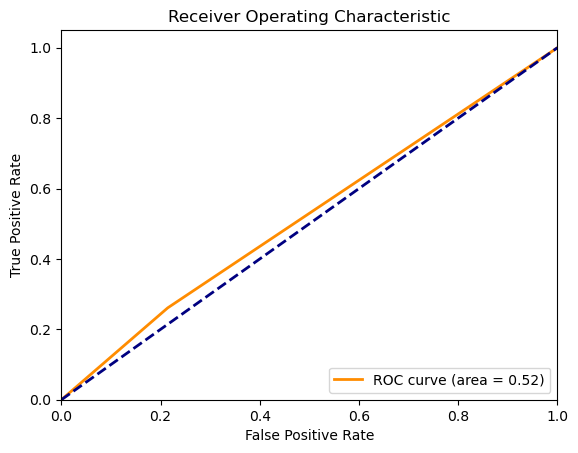

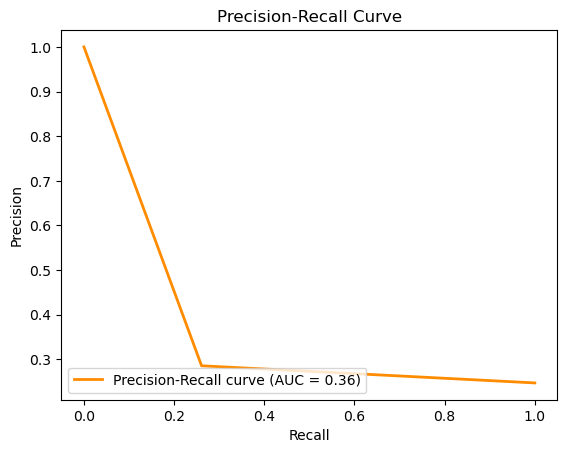

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Set the number of splits (k)
k = 10
totac=[]
# Initialize StratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=k, shuffle=True)

# Perform k-stratified sampling
for train_index, test_index in stratified_kfold.split(covid.iloc[:, :-1], covid.iloc[:, -1]):
    train_data, test_data = covid.iloc[train_index], covid.iloc[test_index]
    #creating the model
    bnmodel = BayesianNetwork([
    #background (4)
    ('Gender','COVI19_PCR'),('Age_group','COVI19_PCR'),('Smoker','COVI19_PCR'),
    ('under_cond','COVI19_PCR'),('SymptomDays','COVI19_PCR'),
    #symptoms (17)
    ('Cold','COVI19_PCR'),('Cough','COVI19_PCR'),('MuscularPain','COVI19_PCR'),
    ('BreatheDiff','COVI19_PCR'),('Headache','COVI19_PCR'),('Ageusia','COVI19_PCR'),
    ('Odynophagia','COVI19_PCR'),('SoreThroat','COVI19_PCR'),('Fatigue','COVI19_PCR'),
    ('Stomach','COVI19_PCR'),('CloggedNose','COVI19_PCR'),
    ('ChestPain','COVI19_PCR'),('Dizziness','COVI19_PCR'),('Shivers','COVI19_PCR'),
    ('LossAppetite','COVI19_PCR'),('Fever','COVI19_PCR'),('Anosmia','COVI19_PCR'),
    #underlying conditions (6)
    ('RinitisSinusitis','under_cond'),('RespiratoryAllegies','under_cond'),
    ('Hypertension','under_cond'),('Diabetes','under_cond'),('Asthma','under_cond'),
    ('Hypothyroidism','under_cond')
])
    
    #adding cpds
    bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,ResAlcpd,RinSinAlcpd,Hypocpd, #6
                 Gendcpd,Agecpd,Smokecpd, #3
                 Coldcpd,Coughcpd,MPcpd,BDcpd,Headachecpd,Anosmiacpd, #6
                 Ageusiacpd,Odynophagiacpd,Sorethroatcpd,Fatiguecpd, #4
                 Stomachcpd,Cloggedcpd,ChestPaincpd,Dizzcpd,Shiverscpd,#5
                 LossAppcpd,Fevercpd) #2
    #training the model
    

    estimator = BayesianEstimator(bnmodel,train_data)
    COVIDcpd = estimator.estimate_cpd('COVI19_PCR')
    UCcpd = estimator.estimate_cpd('under_cond')
    SDayscpd = estimator.estimate_cpd('SymptomDays')
    
    
    bnmodel.add_cpds(COVIDcpd,UCcpd,SDayscpd)
    infer=VariableElimination(bnmodel)
    #defining features and target
    target = "COVI19_PCR"
    # Define features as all columns except the target variable
    features = covid.drop(columns=[target]).columns.tolist()
    # Split the dataset into train and test sets
    
# Split the dataset into training and testing sets
    X_test, y_test = (test_data[features], test_data['COVI19_PCR'])
    inference = VariableElimination(bnmodel)
    predictions = []
    for i in range(len(X_test)):
        evidence = X_valid.iloc[i].to_dict()
        query = 'COVI19_PCR'
        factor = inference.query([query], evidence=evidence)
        prediction = factor.values[1]
        predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
    newpred=[]
    for i in range(len(predictions)):
        if predictions[i]>=0.870:
            newpred.append(1)
        else:
                newpred.append(0)
                
    # setting up the threshold value such that, we start with a threshold of 0.5
    from sklearn.metrics import confusion_matrix
    true_labels = y_test
    predicted_labels = newpred
    cm = confusion_matrix(true_labels, predicted_labels)
    print(cm)
    # Extracting the values from the confusion matrix
    TN, FP, FN, TP = cm.ravel()
    # Calculating accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print("Accuracy:", accuracy)
    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    
    # Calculate precision and recall values for different thresholds
    precision, recall, thresholds = precision_recall_curve(true_labels, predicted_labels)
    # Calculate Area Under the Precision-Recall curve (AUC-PR)
    auc_pr = auc(recall, precision)
    # Plot Precision-Recall curve
    plt.figure()
    plt.plot(recall, precision, color='darkorange', lw=2, label='Precision-Recall curve (AUC = %0.2f)' % auc_pr)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()
    totac.append(accuracy)

print("Average accuracy:", np.mean(totac))


In [ ]:
end_time = time.time()

elapsed_time = end_time - start_time
print(elapsed_time)

In [ ]:
covid.columns

### Neural Network

In [ ]:
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

X = features
y = target

# K-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True)
accuracies = []

for train_idx, val_idx in kfold.split(X):
    X_train, X_val = covid[X].iloc[train_idx], covid[X].iloc[val_idx]
    y_train, y_val = covid[y].iloc[train_idx], covid[y].iloc[val_idx]
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    
    accuracy = model.evaluate(X_val, y_val)[1]
    accuracies.append(accuracy)

average_accuracy = np.mean(accuracies)
print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')

In [ ]:
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
dropthis = ["Age_group", "Asthma", #"12__Other_COMMENTS",
            "Hypothyroidism", "Dizziness", "under_cond", "Stomach"]
covidnn = covid.drop(dropthis, axis=1)
#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covidnn.drop(columns=[target]).columns.tolist()
X = features
y = target

# K-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True)
accuracies = []

for train_idx, val_idx in kfold.split(X):
    X_train, X_val = covidnn[X].iloc[train_idx], covidnn[X].iloc[val_idx]
    y_train, y_val = covidnn[y].iloc[train_idx], covidnn[y].iloc[val_idx]
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)
    
    accuracy = model.evaluate(X_val, y_val)[1]
    accuracies.append(accuracy)

average_accuracy = np.mean(accuracies)
print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')

In [ ]:
kfold = KFold(n_splits=10, shuffle=True)
accuracies = []
avgacc=[]
for train_idx, val_idx in kfold.split(X):
    X_train, X_val = covidnn[X].iloc[train_idx], covidnn[X].iloc[val_idx]
    y_train, y_val = covidnn[y].iloc[train_idx], covidnn[y].iloc[val_idx]
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    # Use the Gradient Descent optimizer
    for learning_rate in np.arange(0.01, 0.1, 0.01):
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)  
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)
        accuracy = model.evaluate(X_val, y_val)[1]
        accuracies.append(accuracy)
    average_accuracy = np.mean(accuracies)
    avgacc.append(average_accuracy)

#average_accuracy = np.mean(accuracies)
#print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')


In [ ]:
print(avgacc)
lr=np.arange(0.01, 0.11, 0.01)
plt.plot(lr, avgacc, marker='o', linestyle='-', color='b', label='Line Curve')
plt.xlabel('learningrate')
plt.ylabel('accuracy')
plt.title('Line Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
X = features
y = target
train_losses = []
val_losses = []

# K-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True)
accuracies = []

for train_idx, val_idx in kfold.split(X):
    X_train, X_val = covidnn[X].iloc[train_idx], covidnn[X].iloc[val_idx]
    y_train, y_val = covidnn[y].iloc[train_idx], covidnn[y].iloc[val_idx]
    
    
    
    
    model = tf.keras.Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(8, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(1, activation='relu')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Add early stopping callback
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history=model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1, validation_data=(X_val, y_val), callbacks=[early_stopping])
    
    accuracy = model.evaluate(X_val, y_val, verbose=0)[1]
    accuracies.append(accuracy)
    
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

average_accuracy = np.mean(accuracies)
print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')


plt.figure(figsize=(10, 10))

for i in range(len(train_losses)):
    plt.plot(train_losses[i], label=f'Fold {i+1} - Training')
    plt.plot(val_losses[i], label=f'Fold {i+1} - Validation')

plt.title('Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf
from sklearn.model_selection import KFold

X = features
y = target

# K-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True)
accuracies = []

for train_idx, val_idx in kfold.split(X):
    X_train, X_val = covid[X].iloc[train_idx], covid[X].iloc[val_idx]
    y_train, y_val = covid[y].iloc[train_idx], covid[y].iloc[val_idx]
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)
    
    accuracy = model.evaluate(X_val, y_val)[1]
    accuracies.append(accuracy)

average_accuracy = np.mean(accuracies)
print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')

In [ ]:
import tensorflow as tf
from sklearn.model_selection import KFold

X = features
y = target

# K-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True)
accuracies = []

for train_idx, val_idx in kfold.split(X):
    X_train, X_val = covid[X].iloc[train_idx], covid[X].iloc[val_idx]
    y_train, y_val = covid[y].iloc[train_idx], covid[y].iloc[val_idx]
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)
    
    accuracy = model.evaluate(X_val, y_val)[1]
    accuracies.append(accuracy)

average_accuracy = np.mean(accuracies)
print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')

In [ ]:

X = features
y = target
train_losses = []
val_losses = []
accuracies=[]
from sklearn.model_selection import train_test_split


# Set a random seed for reproducibility
random_seed = 42

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(covid[X], covid[y], test_size=0.2, random_state=random_seed)

model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='relu')
    ])
    
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
train_losses = []
val_losses = []

# Training loop over epochs
num_epochs = 50
for epoch in range(num_epochs):
    history = model.fit(X_train, y_train, epochs=1, batch_size=32, verbose=0)
    
    # Record loss values
    train_losses.append(history.history['loss'][0])  
    accuracy = model.evaluate(X_val, y_val)[1]
   
    accuracies.append(accuracy)
    


print(np.mean(accuracies))

import matplotlib.pyplot as plt

# Assuming you have train_losses and val_losses recorded

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


looking at other variations of the model


In [ ]:
bnmodel = BayesianNetwork([('Hypertension', 'COVI19_PCR'),
                       ('Diabetes', 'COVI19_PCR'),
                       ('Cough', 'COVI19_PCR'), ('Fever', 'COVI19_PCR'), ('MuscularPain', 'COVI19_PCR'),
                       ('BreatheDiff', 'COVI19_PCR'), ('SymptomDays', 'COVI19_PCR'), ('Smoker', 'COVI19_PCR'),
                       ('Anosmia', 'COVI19_PCR'), ('Cold', 'Fever'), ('Cold', 'Cough'),
                       ('Age_group', 'MuscularPain'), ('Gender', 'Smoker'),
                       ('RespiratoryAllegies', 'COVI19_PCR'), ('RinitisSinusitis', 'Anosmia'), 
                        ('Age_group','RespiratoryAllegies')
                          ])

In [ ]:
bnmodel.to_daft(node_pos={"Anosmia": (3.3,1),
                          "RinitisSinusitis": (2, 1.3),
                          "Hypertension": (1.4, 2),
                          "Diabetes": (1,3),
                          #"Alzheimer": (1,4),
                          "BreatheDiff": (1.4,4.8),
                          "SymptomDays": (2,5.5),
                          "RespiratoryAllegies": (3,6),
                          "COVI19_PCR": (3,3.5),
                          "Smoker": (4.2,1.5),
                          "MuscularPain": (4.7,2.4),
                          #"Parkinson": (5, 3.5),
                          "Cough": (4.7,4.6),
                          "Fever": (4.2,5.6),
                          "Cold": (6.5,5.1),
                          "Age_group": (7.5,5.7),
                          "Gender": (6.5,1.5)                         
                         }
               ).render()

In [ ]:
Gendcpd = TabularCPD(variable='Gender',
                       variable_card=2,
                       values=[[.5021], [.4979]])

Agecpd = TabularCPD(variable='Age_group',
                       variable_card=5,
                       values=[[.17], [.135], [0.282], [0.242], [0.171]])
#Agecpd.state_names = {'Age_group': age_groups}
RScpd = TabularCPD(variable='RinitisSinusitis',
                       variable_card=2,
                       values=[[0.16], [.84]])
Hypercpd = TabularCPD(variable='Hypertension',
                       variable_card=2,
                       values=[[0.2557], [.7443]])
Diabcpd = TabularCPD(variable='Diabetes',
                       variable_card=2,
                       values=[[.05], [.95]])
BDcpd = TabularCPD(variable='BreatheDiff',
                       variable_card=2,
                       values=[[.032], [.968]])
Coldcpd = TabularCPD(variable='Cold',
                       variable_card=2,
                       values=[[.137], [.863]])


In [ ]:
bnmodel.add_cpds(RScpd, Hypercpd, Diabcpd, BDcpd, #SDayscpd,
                #ResAlcpd, 
                 Coldcpd, Agecpd, MPcpd, 
                Gendcpd
                )

In [ ]:
mle = BayesianEstimator(bnmodel, training_data)

#RScpd = mle.estimate_cpd('RinitisSinusitis')
#Hypercpd = mle.estimate_cpd('Hypertension')
#Diabcpd = mle.estimate_cpd('Diabetes')
#BDcpd = mle.estimate_cpd('BreatheDiff')
SDayscpd = mle.estimate_cpd('SymptomDays')
ResAlcpd = mle.estimate_cpd('RespiratoryAllegies')
#Coldcpd = mle.estimate_cpd('Cold')
#Agecpd = mle.estimate_cpd('Age_group')
MPcpd = mle.estimate_cpd('MuscularPain')
#Gendcpd = mle.estimate_cpd('Gender')
Anoscpd = mle.estimate_cpd('Anosmia')
Smokcpd = mle.estimate_cpd('Smoker')
Coughcpd = mle.estimate_cpd('Cough')
Fevercpd = mle.estimate_cpd('Fever')
COVIDcpd = mle.estimate_cpd('COVI19_PCR')

In [ ]:
bnmodel.add_cpds(COVIDcpd, Fevercpd, Coughcpd, Smokcpd, Anoscpd
                , SDayscpd#, Gendcpd, Agecpd, Coldcpd
                 , ResAlcpd
                #, BDcpd, Diabcpd, Hypercpd, RScpd
                 ,MPcpd
                )

In [ ]:
# print the state counts for each node
cpds = bnmodel.get_cpds()
for cpd in cpds:
    print(cpd)

In [ ]:
infer=VariableElimination(bnmodel)

In [ ]:
evidence = {'Smoker': 0, 'Age_group': 2, 'Fever': 1, 'Cough':1} #0 is true
print(infer.query(['COVI19_PCR'], evidence=evidence))

In [ ]:
#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target]).columns.tolist()

In [ ]:
# Split the data into training and testing set using 10-fold stratified sampling
from sklearn.model_selection import train_test_split

# Assuming your dataset is stored in 'X' (features) and 'y' (target variable)

# Split the dataset into training and testing sets
X_test=testing_data[features]
y_test=testing_data[target]

In [ ]:
inference = VariableElimination(bnmodel)
predictions = []
for i in range(len(X_test)):
    #here we note that we want to predict covid and we take the values 1 by 1
    #we form a new dataset for the predictions
    #the predictions fall between 0 and 1
    #we thus have to decide a threshold value that determines covid positive or negative
    evidence = X_test.iloc[i].to_dict()
    query = 'COVI19_PCR'
    factor = inference.query([query], evidence=evidence)
    prediction = factor.values[1]
    predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
newpred=[]
for i in range(len(predictions)):
    if predictions[i]>=0.50:
        newpred.append(1)
    else:
        newpred.append(0)

In [ ]:
# setting up the threshold value such that, we start with a threshold of 0.5
from sklearn.metrics import confusion_matrix

# Assuming you ha]ve the true labels and predicted labels
true_labels = y_test
predicted_labels = newpred

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)


# Extracting the values from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculating accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Set the number of splits (k)
k = 5
totac=[]
# Initialize StratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=k, shuffle=True)

# Perform k-stratified sampling
for train_index, test_index in stratified_kfold.split(covid_symp.iloc[:, :-1], covid_symp.iloc[:, -1]):
    train_data, test_data = covid_symp.iloc[train_index], covid_symp.iloc[test_index]
    #creating the model
    X_valid, X_test, y_valid, y_test = train_test_split(test_data[features], test_data[target], test_size=0.35, random_state=42)
    
    inference = VariableElimination(bnmodel)
    predictions = []
    for i in range(len(X_valid)):
        evidence = X_valid.iloc[i].to_dict()
        query = 'COVI19_PCR'
        factor = inference.query([query], evidence=evidence)
        prediction = factor.values[1]
        predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
    newpred=[]
    for i in range(len(predictions)):
        if predictions[i]>=0.70:
            newpred.append(1)
        else:
                newpred.append(0)
                
    # setting up the threshold value such that, we start with a threshold of 0.5
    from sklearn.metrics import confusion_matrix
    true_labels = y_valid
    predicted_labels = newpred
    cm = confusion_matrix(true_labels, predicted_labels)
    print(cm)
    # Extracting the values from the confusion matrix
    TN, FP, FN, TP = cm.ravel()
    # Calculating accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print("Accuracy:", accuracy)
    totac.append(accuracy)
    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    

print("Average accuracy:", np.mean(totac))


new model


In [ ]:
covid.columns

In [ ]:
bnmodel = BayesianNetwork([
    #background (4)
    ('Gender','under_cond'),('Age_group','under_cond'),('Smoker','under_cond'),
    ('SymptomDays','under_cond'),
    ('under_cond','COVI19_PCR'),
    #backtocov
    ('Gender','COVI19_PCR'),('Age_group','COVI19_PCR'),('Smoker','COVI19_PCR'),
    ('SymptomDays','COVI19_PCR'),
    #symptoms (17)
    ('COVI19_PCR','Cold'),('COVI19_PCR','Cough'),('COVI19_PCR','MuscularPain'),
    ('COVI19_PCR','BreatheDiff'),('COVI19_PCR','Headache'),('COVI19_PCR','Ageusia'),
    ('COVI19_PCR','Odynophagia'),('COVI19_PCR','SoreThroat'),('COVI19_PCR','Fatigue'),
    ('COVI19_PCR','Stomach'),('COVI19_PCR','CloggedNose'),
    ('COVI19_PCR','ChestPain'),('COVI19_PCR','Dizziness'),('COVI19_PCR','Shivers'),
    ('COVI19_PCR','LossAppetite'),('COVI19_PCR','Fever'),('COVI19_PCR','Anosmia'),
    #underlying conditions (6)
    ('RinitisSinusitis','under_cond'),('RespiratoryAllegies','under_cond'),
    ('Hypertension','under_cond'),('Diabetes','under_cond'),('Asthma','under_cond'),
    ('Hypothyroidism','under_cond')
])

In [ ]:
covidpgm = PGM(shape=[15,12])
covidpgm.add_node(daft.Node('Gender','Gend',4,10, scale=1.5))
covidpgm.add_node(daft.Node('SymptomDays','Symp\nDays',6,9, scale=1.5))
covidpgm.add_node(daft.Node('Smoker','Smoker',6,8, scale=1.5))
covidpgm.add_node(daft.Node('Age_group','Age\nGroup',3,5, scale=1.5))
covidpgm.add_node(daft.Node('under_cond','Under\nCond',4,6,scale=1.5))
covidpgm.add_node(daft.Node('COVI19_PCR','Covid',2,5, scale=1.5))

covidpgm.add_node(daft.Node('RinitisSinusitis','Rinitis\nSinusitis',6,6,scale=1.5))
covidpgm.add_node(daft.Node('RespiratoryAllegies','Respiratory\nAllergies',6,5,scale=1.5))
covidpgm.add_node(daft.Node('Hypertension','Hyper\ntension',6,4,scale=1.5))
covidpgm.add_node(daft.Node('Diabetes','Diabetes',6,3,scale=1.5))
covidpgm.add_node(daft.Node('Hypothyroidism','Hypothy\nroidism',6,2,scale=1.5))
covidpgm.add_node(daft.Node('Asthma','Asthma',6,1,scale=1.5))

covidpgm.add_node(daft.Node('Cold','Cold',0,1,scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',0,2,scale=1.5))
covidpgm.add_node(daft.Node('MuscularPain','Muscular\nPain',0,3,scale=1.5))
covidpgm.add_node(daft.Node('BreatheDiff','Breathe\nDifficulty',0,4,scale=1.5))
covidpgm.add_node(daft.Node('Headache','Headache',0,5,scale=1.5))
covidpgm.add_node(daft.Node('Ageusia','Ageusia',0,6,scale=1.5))
covidpgm.add_node(daft.Node('Odynophagia','Odyno\nphagia',0,7,scale=1.5))
covidpgm.add_node(daft.Node('SoreThroat','Sore\nThroat',0,8,scale=1.5))
covidpgm.add_node(daft.Node('Fatigue','Fatigue',0,9,scale=1.5))
covidpgm.add_node(daft.Node('Stomach','Stomach',0,10,scale=1.5))
covidpgm.add_node(daft.Node('CloggedNose','Clogged\nNose',1,10,scale=1.5))
covidpgm.add_node(daft.Node('ChestPain','Chest\nPain',2,10,scale=1.5))
covidpgm.add_node(daft.Node('Dizziness','Dizziness',5,1,scale=1.5))
covidpgm.add_node(daft.Node('Shivers','Shivers',1,1,scale=1.5))
covidpgm.add_node(daft.Node('LossAppetite','Loss\nAppetite',2,1,scale=1.5))
covidpgm.add_node(daft.Node('Fever','Fever',3,1,scale=1.5))
covidpgm.add_node(daft.Node('Anosmia','Anosmia',4,1,scale=1.5))

In [ ]:
covidpgm.add_edge('Gender','under_cond')
covidpgm.add_edge('Age_group','under_cond')
covidpgm.add_edge('Smoker','under_cond')
covidpgm.add_edge('SymptomDays','under_cond')
    #symptoms (18)
covidpgm.add_edge('COVI19_PCR','Cold')
covidpgm.add_edge('COVI19_PCR','Cough')
covidpgm.add_edge('COVI19_PCR','MuscularPain')
covidpgm.add_edge('COVI19_PCR','BreatheDiff')
covidpgm.add_edge('COVI19_PCR','Headache')
covidpgm.add_edge('COVI19_PCR','Ageusia')
covidpgm.add_edge('COVI19_PCR','Odynophagia')
covidpgm.add_edge('COVI19_PCR','SoreThroat')
covidpgm.add_edge('COVI19_PCR','Fatigue')
covidpgm.add_edge('COVI19_PCR','Stomach')
covidpgm.add_edge('COVI19_PCR','CloggedNose')
covidpgm.add_edge ('COVI19_PCR','ChestPain')
covidpgm.add_edge('COVI19_PCR','Dizziness')
covidpgm.add_edge('COVI19_PCR','Shivers')
covidpgm.add_edge('COVI19_PCR','LossAppetite')
covidpgm.add_edge('COVI19_PCR','Fever')
covidpgm.add_edge('COVI19_PCR','Anosmia')
    #underlying conditions (6)
covidpgm.add_edge('RinitisSinusitis','under_cond')
covidpgm.add_edge('RespiratoryAllegies','under_cond')
covidpgm.add_edge('Hypertension','under_cond')
covidpgm.add_edge('Diabetes','under_cond')
covidpgm.add_edge('Asthma','under_cond')
covidpgm.add_edge('Hypothyroidism','under_cond')
#backtocov
covidpgm.add_edge ('Gender','COVI19_PCR')
covidpgm.add_edge('Age_group','COVI19_PCR')
covidpgm.add_edge('Smoker','COVI19_PCR')
covidpgm.add_edge('SymptomDays','COVI19_PCR')
covidpgm.add_edge('under_cond','COVI19_PCR')



In [ ]:
covidpgm.render()
plt.show()

In [ ]:
target = 'COVI19_PCR'
features = covid.drop(columns=[target])
target = covid[target]

In [ ]:
Hypercpd = TabularCPD(variable='Hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='Diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='Asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%
ResAlcpd = TabularCPD(variable='RespiratoryAllegies',
                       variable_card=2,
                       values=[[.19], [.81]])
RinSinAlcpd = TabularCPD(variable='RinitisSinusitis',
                       variable_card=2,
                       values=[[.196], [.804]]) #union from AIHW 19.6%
Hypocpd = TabularCPD(variable='Hypothyroidism',
                       variable_card=2,
                       values=[[.046], [.954]])
Gendcpd = TabularCPD(variable='Gender',
                       variable_card=2,
                       values=[[.5021], [.4979]]) #from ABS population
Agecpd = TabularCPD(variable='Age_group', #from ABS 
                       variable_card=5,
                       values=[[.17], [.135], [0.282], [0.242], [0.171]])
Smokecpd = TabularCPD(variable='Smoker',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%


In [ ]:
bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,ResAlcpd,RinSinAlcpd,Hypocpd, #6
                 Gendcpd,Agecpd,Smokecpd, #3
                 
        ) 

In [ ]:
# Split the dataset into train and test sets
training_data, testing_data = train_test_split(covid, test_size=0.35, random_state=42)

In [ ]:
estimator = BayesianEstimator(bnmodel,training_data)
COVIDcpd = estimator.estimate_cpd('COVI19_PCR')
UCcpd = estimator.estimate_cpd('under_cond')
SDayscpd = estimator.estimate_cpd('SymptomDays')
Coldcpd=estimator.estimate_cpd('Cold')
Coughcpd=estimator.estimate_cpd('Cough')
MPcpd=estimator.estimate_cpd('MuscularPain')
BDcpd =estimator.estimate_cpd('BreatheDiff')
Headachecpd=estimator.estimate_cpd('Headache')
Anosmiacpd=estimator.estimate_cpd('Anosmia')
Ageusiacpd=estimator.estimate_cpd('Ageusia')
Odynophagiacpd=estimator.estimate_cpd('Odynophagia')
Sorethroatcpd=estimator.estimate_cpd('SoreThroat')
Fatiguecpd=estimator.estimate_cpd('Fatigue')
Stomachcpd=estimator.estimate_cpd('Stomach')
Cloggedcpd=estimator.estimate_cpd('CloggedNose')
ChestPaincpd=estimator.estimate_cpd('ChestPain')
Dizzcpd=estimator.estimate_cpd('Dizziness')
Shiverscpd=estimator.estimate_cpd('Shivers')
Fevercpd=estimator.estimate_cpd('Fever')
LossAppcpd=estimator.estimate_cpd('LossAppetite')

In [ ]:
bnmodel.add_cpds(COVIDcpd,UCcpd,SDayscpd,
                Coldcpd,Coughcpd,MPcpd,BDcpd,Headachecpd,Anosmiacpd, #6
                 Ageusiacpd,Odynophagiacpd,Sorethroatcpd,Fatiguecpd, #4
                 Stomachcpd,Cloggedcpd,ChestPaincpd,Dizzcpd,Shiverscpd,#5
                 LossAppcpd,Fevercpd)

In [ ]:
infer=VariableElimination(bnmodel)

In [ ]:
evidence = {'Smoker': 0,'Asthma':1, 'Fever': 1, 'Cough':1, 'Anosmia':1,'BreatheDiff':1,'SymptomDays':3} #0 is false
print(infer.query(['COVI19_PCR'], evidence=evidence))

In [ ]:
predictions = []
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = 'COVI19_PCR'
    factor = infer.query([query], evidence=evidence)
    prediction = factor.values[1]
    predictions.append(prediction)

newpred=[]
for i in range(len(predictions)):
    if predictions[i]>=.70: # start with a threshold of 0.5
        newpred.append(1)
    else:
        newpred.append(0)

In [ ]:

true_labels = y_test
predicted_labels = newpred


cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

In [ ]:
# Extracting the values from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculating accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Set the number of splits (k)
bnmodel = BayesianNetwork([
    #background (4)
    ('Gender','under_cond'),('Age_group','under_cond'),('Smoker','under_cond'),
    ('SymptomDays','under_cond'),
    ('under_cond','COVI19_PCR'),
    #backtocov
    ('Gender','COVI19_PCR'),('Age_group','COVI19_PCR'),('Smoker','COVI19_PCR'),
    ('SymptomDays','COVI19_PCR'),
    #symptoms (17)
    ('COVI19_PCR','Cold'),('COVI19_PCR','Cough'),('COVI19_PCR','MuscularPain'),
    ('COVI19_PCR','BreatheDiff'),('COVI19_PCR','Headache'),('COVI19_PCR','Ageusia'),
    ('COVI19_PCR','Odynophagia'),('COVI19_PCR','SoreThroat'),('COVI19_PCR','Fatigue'),
    ('COVI19_PCR','Stomach'),('COVI19_PCR','CloggedNose'),
    ('COVI19_PCR','ChestPain'),('COVI19_PCR','Dizziness'),('COVI19_PCR','Shivers'),
    ('COVI19_PCR','LossAppetite'),('COVI19_PCR','Fever'),('COVI19_PCR','Anosmia'),
    #underlying conditions (6)
    ('RinitisSinusitis','under_cond'),('RespiratoryAllegies','under_cond'),
    ('Hypertension','under_cond'),('Diabetes','under_cond'),('Asthma','under_cond'),
    ('Hypothyroidism','under_cond')
])
    
k = 10
totac=[]
# Initialize StratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=k, shuffle=True)

# Perform k-stratified sampling
for train_index, test_index in stratified_kfold.split(covid.iloc[:, :-1], covid.iloc[:, -1]):
    train_data, test_data = covid.iloc[train_index], covid.iloc[test_index]
    #creating the model
    
    #adding cpds
    bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,ResAlcpd,RinSinAlcpd,Hypocpd, #6
                 Gendcpd,Agecpd,Smokecpd, #3
                 
        ) #2
    #training the model
    

    estimator = BayesianEstimator(bnmodel,train_data)
    COVIDcpd = estimator.estimate_cpd('COVI19_PCR')
    UCcpd = estimator.estimate_cpd('under_cond')
    SDayscpd = estimator.estimate_cpd('SymptomDays')
    Coldcpd=estimator.estimate_cpd('Cold')
    Coughcpd=estimator.estimate_cpd('Cough')
    MPcpd=estimator.estimate_cpd('MuscularPain')
    BDcpd =estimator.estimate_cpd('BreatheDiff')
    Headachecpd=estimator.estimate_cpd('Headache')
    Anosmiacpd=estimator.estimate_cpd('Anosmia')
    Ageusiacpd=estimator.estimate_cpd('Ageusia')
    Odynophagiacpd=estimator.estimate_cpd('Odynophagia')
    Sorethroatcpd=estimator.estimate_cpd('SoreThroat')
    Fatiguecpd=estimator.estimate_cpd('Fatigue')
    Stomachcpd=estimator.estimate_cpd('Stomach')
    Cloggedcpd=estimator.estimate_cpd('CloggedNose')
    ChestPaincpd=estimator.estimate_cpd('ChestPain')
    Dizzcpd=estimator.estimate_cpd('Dizziness')
    Shiverscpd=estimator.estimate_cpd('Shivers')
    Fevercpd=estimator.estimate_cpd('Fever')
    LossAppcpd=estimator.estimate_cpd('LossAppetite')
    
    bnmodel.add_cpds(COVIDcpd,UCcpd,SDayscpd,
                Coldcpd,Coughcpd,MPcpd,BDcpd,Headachecpd,Anosmiacpd, #6
                 Ageusiacpd,Odynophagiacpd,Sorethroatcpd,Fatiguecpd, #4
                 Stomachcpd,Cloggedcpd,ChestPaincpd,Dizzcpd,Shiverscpd,#5
                 LossAppcpd,Fevercpd)
    infer=VariableElimination(bnmodel)
    #defining features and target
    target = "COVI19_PCR"
    # Define features as all columns except the target variable
    features = covid.drop(columns=[target]).columns.tolist()
    # Split the dataset into train and test sets
    
# Split the dataset into training and testing sets
    X_test, y_test = (test_data[features], test_data['COVI19_PCR'])
    inference = VariableElimination(bnmodel)
    predictions = []
    for i in range(len(X_test)):
        evidence = X_valid.iloc[i].to_dict()
        query = 'COVI19_PCR'
        factor = inference.query([query], evidence=evidence)
        prediction = factor.values[1]
        predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
    newpred=[]
    for i in range(len(predictions)):
        if predictions[i]>=0.90:
            newpred.append(1)
        else:
                newpred.append(0)
                
    # setting up the threshold value such that, we start with a threshold of 0.5
    from sklearn.metrics import confusion_matrix
    true_labels = y_test
    predicted_labels = newpred
    cm = confusion_matrix(true_labels, predicted_labels)
    print(cm)
    # Extracting the values from the confusion matrix
    TN, FP, FN, TP = cm.ravel()
    # Calculating accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print("Accuracy:", accuracy)
    totac.append(accuracy)
    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    
    
    
print("Average accuracy:", np.mean(totac))


new network.

In [ ]:
bnmodel = BayesianNetwork([
    #background (4)
    ('Gender','under_cond'),('Age_group','under_cond'),('Smoker','under_cond'),
    ('SymptomDays','under_cond'),
    ('under_cond','COVI19_PCR'),
    
    #symptoms (17)
    ('COVI19_PCR','Cold'),('COVI19_PCR','Cough'),('COVI19_PCR','MuscularPain'),
    ('COVI19_PCR','BreatheDiff'),('COVI19_PCR','Headache'),('COVI19_PCR','Ageusia'),
    ('COVI19_PCR','Odynophagia'),('COVI19_PCR','SoreThroat'),('COVI19_PCR','Fatigue'),
    ('COVI19_PCR','Stomach'),('COVI19_PCR','CloggedNose'),
    ('COVI19_PCR','ChestPain'),('COVI19_PCR','Dizziness'),('COVI19_PCR','Shivers'),
    ('COVI19_PCR','LossAppetite'),('COVI19_PCR','Fever'),('COVI19_PCR','Anosmia'),
    #underlying conditions (6)
    ('RinitisSinusitis','under_cond'),('RespiratoryAllegies','under_cond'),
    ('Hypertension','under_cond'),('Diabetes','under_cond'),('Asthma','under_cond'),
    ('Hypothyroidism','under_cond')
])

In [ ]:
covidpgm = PGM(shape=[15,15])
covidpgm.add_node(daft.Node('Gender','Gend',4,10, scale=1.5))
covidpgm.add_node(daft.Node('SymptomDays','Symp\nDays',6,9, scale=1.5))
covidpgm.add_node(daft.Node('Smoker','Smoker',6,8, scale=1.5))
covidpgm.add_node(daft.Node('Age_group','Age\nGroup',3,5, scale=1.5))
covidpgm.add_node(daft.Node('under_cond','Under\nCond',4,6,scale=1.5))
covidpgm.add_node(daft.Node('COVI19_PCR','Covid',2,5, scale=1.5))

covidpgm.add_node(daft.Node('RinitisSinusitis','Rinitis\nSinusitis',6,6,scale=1.5))
covidpgm.add_node(daft.Node('RespiratoryAllegies','Respiratory\nAllergies',6,5,scale=1.5))
covidpgm.add_node(daft.Node('Hypertension','Hyper\ntension',6,4,scale=1.5))
covidpgm.add_node(daft.Node('Diabetes','Diabetes',6,3,scale=1.5))
covidpgm.add_node(daft.Node('Hypothyroidism','Hypothy\nroidism',6,2,scale=1.5))
covidpgm.add_node(daft.Node('Asthma','Asthma',6,1,scale=1.5))

covidpgm.add_node(daft.Node('Cold','Cold',0,1,scale=1.5))
covidpgm.add_node(daft.Node('Cough','Cough',0,2,scale=1.5))
covidpgm.add_node(daft.Node('MuscularPain','Muscular\nPain',0,3,scale=1.5))
covidpgm.add_node(daft.Node('BreatheDiff','Breathe\nDifficulty',0,4,scale=1.5))
covidpgm.add_node(daft.Node('Headache','Headache',0,5,scale=1.5))
covidpgm.add_node(daft.Node('Ageusia','Ageusia',0,6,scale=1.5))
covidpgm.add_node(daft.Node('Odynophagia','Odyno\nphagia',0,7,scale=1.5))
covidpgm.add_node(daft.Node('SoreThroat','Sore\nThroat',0,8,scale=1.5))
covidpgm.add_node(daft.Node('Fatigue','Fatigue',0,9,scale=1.5))
covidpgm.add_node(daft.Node('Stomach','Stomach',0,10,scale=1.5))
covidpgm.add_node(daft.Node('CloggedNose','Clogged\nNose',1,10,scale=1.5))
covidpgm.add_node(daft.Node('ChestPain','Chest\nPain',2,10,scale=1.5))
covidpgm.add_node(daft.Node('Dizziness','Dizziness',5,1,scale=1.5))
covidpgm.add_node(daft.Node('Shivers','Shivers',1,1,scale=1.5))
covidpgm.add_node(daft.Node('LossAppetite','Loss\nAppetite',2,1,scale=1.5))
covidpgm.add_node(daft.Node('Fever','Fever',3,1,scale=1.5))
covidpgm.add_node(daft.Node('Anosmia','Anosmia',4,1,scale=1.5))

In [ ]:
covidpgm.add_edge('Gender','under_cond')
covidpgm.add_edge('Age_group','under_cond')
covidpgm.add_edge('Smoker','under_cond')
covidpgm.add_edge('SymptomDays','under_cond')
    #symptoms (18)
covidpgm.add_edge('COVI19_PCR','Cold')
covidpgm.add_edge('COVI19_PCR','Cough')
covidpgm.add_edge('COVI19_PCR','MuscularPain')
covidpgm.add_edge('COVI19_PCR','BreatheDiff')
covidpgm.add_edge('COVI19_PCR','Headache')
covidpgm.add_edge('COVI19_PCR','Ageusia')
covidpgm.add_edge('COVI19_PCR','Odynophagia')
covidpgm.add_edge('COVI19_PCR','SoreThroat')
covidpgm.add_edge('COVI19_PCR','Fatigue')
covidpgm.add_edge('COVI19_PCR','Stomach')
covidpgm.add_edge('COVI19_PCR','CloggedNose')
covidpgm.add_edge ('COVI19_PCR','ChestPain')
covidpgm.add_edge('COVI19_PCR','Dizziness')
covidpgm.add_edge('COVI19_PCR','Shivers')
covidpgm.add_edge('COVI19_PCR','LossAppetite')
covidpgm.add_edge('COVI19_PCR','Fever')
covidpgm.add_edge('COVI19_PCR','Anosmia')
    #underlying conditions (6)
covidpgm.add_edge('RinitisSinusitis','under_cond')
covidpgm.add_edge('RespiratoryAllegies','under_cond')
covidpgm.add_edge('Hypertension','under_cond')
covidpgm.add_edge('Diabetes','under_cond')
covidpgm.add_edge('Asthma','under_cond')
covidpgm.add_edge('Hypothyroidism','under_cond')
covidpgm.add_edge('under_cond','COVI19_PCR')

In [ ]:
covidpgm.render()
plt.show()

In [ ]:
target = 'COVI19_PCR'
features = covid.drop(columns=[target])
target = covid[target]

In [ ]:
Hypercpd = TabularCPD(variable='Hypertension',
                       variable_card=2,
                       values=[[0.34], [.66]]) #AIHW 34%
Diabcpd = TabularCPD(variable='Diabetes',
                       variable_card=2,
                       values=[[.049], [.951]]) #AIHW 4.9%
Asthmacpd = TabularCPD(variable='Asthma',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%
ResAlcpd = TabularCPD(variable='RespiratoryAllegies',
                       variable_card=2,
                       values=[[.19], [.81]])
RinSinAlcpd = TabularCPD(variable='RinitisSinusitis',
                       variable_card=2,
                       values=[[.196], [.804]]) #union from AIHW 19.6%
Hypocpd = TabularCPD(variable='Hypothyroidism',
                       variable_card=2,
                       values=[[.046], [.954]])
Gendcpd = TabularCPD(variable='Gender',
                       variable_card=2,
                       values=[[.5021], [.4979]]) #from ABS population
Agecpd = TabularCPD(variable='Age_group', #from ABS 
                       variable_card=5,
                       values=[[.17], [.135], [0.282], [0.242], [0.171]])
Smokecpd = TabularCPD(variable='Smoker',
                       variable_card=2,
                       values=[[.11], [.89]]) #AIHW 11%


In [ ]:
bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,ResAlcpd,RinSinAlcpd,Hypocpd, #6
                 Gendcpd,Agecpd,Smokecpd, #3
                 
        ) 

In [ ]:
# Split the dataset into train and test sets
training_data, testing_data = train_test_split(covid, test_size=0.35, random_state=42)

In [ ]:
estimator = BayesianEstimator(bnmodel,training_data)
COVIDcpd = estimator.estimate_cpd('COVI19_PCR')
UCcpd = estimator.estimate_cpd('under_cond')
SDayscpd = estimator.estimate_cpd('SymptomDays')
Coldcpd=estimator.estimate_cpd('Cold')
Coughcpd=estimator.estimate_cpd('Cough')
MPcpd=estimator.estimate_cpd('MuscularPain')
BDcpd =estimator.estimate_cpd('BreatheDiff')
Headachecpd=estimator.estimate_cpd('Headache')
Anosmiacpd=estimator.estimate_cpd('Anosmia')
Ageusiacpd=estimator.estimate_cpd('Ageusia')
Odynophagiacpd=estimator.estimate_cpd('Odynophagia')
Sorethroatcpd=estimator.estimate_cpd('SoreThroat')
Fatiguecpd=estimator.estimate_cpd('Fatigue')
Stomachcpd=estimator.estimate_cpd('Stomach')
Cloggedcpd=estimator.estimate_cpd('CloggedNose')
ChestPaincpd=estimator.estimate_cpd('ChestPain')
Dizzcpd=estimator.estimate_cpd('Dizziness')
Shiverscpd=estimator.estimate_cpd('Shivers')
Fevercpd=estimator.estimate_cpd('Fever')
LossAppcpd=estimator.estimate_cpd('LossAppetite')

In [ ]:
bnmodel.add_cpds(COVIDcpd,UCcpd,SDayscpd,
                Coldcpd,Coughcpd,MPcpd,BDcpd,Headachecpd,Anosmiacpd, #6
                 Ageusiacpd,Odynophagiacpd,Sorethroatcpd,Fatiguecpd, #4
                 Stomachcpd,Cloggedcpd,ChestPaincpd,Dizzcpd,Shiverscpd,#5
                 LossAppcpd,Fevercpd)

In [ ]:
infer=VariableElimination(bnmodel)

In [ ]:
evidence = {'Smoker': 0,'Asthma':0, 'Fever': 1, 'Cough':1, 'Anosmia':0,'BreatheDiff':1,'SymptomDays':3} #0 is false
print(infer.query(['COVI19_PCR'], evidence=evidence))

In [ ]:
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target]).columns.tolist()


X_test = testing_data[features]
y_test = testing_data[target]
    

In [ ]:
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target]).columns.tolist()


X_test = test_data[features]
y_test = test_data[target]
    

predictions = []
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = 'COVI19_PCR'
    factor = infer.query([query], evidence=evidence)
    prediction = factor.values[1]
    predictions.append(prediction)

newpred=[]
for i in range(len(predictions)):
    if predictions[i]>=.60: # start with a threshold of 0.5
        newpred.append(1)
    else:
        newpred.append(0)

In [ ]:
true_labels = y_test
predicted_labels = newpred


cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

In [ ]:
k = 5
totac=[]
# Initialize StratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=k, shuffle=True)

# Perform k-stratified sampling
for train_index, test_index in stratified_kfold.split(covid.iloc[:, :-1], covid.iloc[:, -1]):
    train_data, test_data = covid.iloc[train_index], covid.iloc[test_index]
    #creating the model
    target = "COVI19_PCR"
# Define features as all columns except the target variable
    features = covid_symp.drop(columns=[target]).columns.tolist()


    X_test = test_data[features]
    y_test = test_data[target]
    
    bnmodel = BayesianNetwork([
    #background (4)
    ('Gender','under_cond'),('Age_group','under_cond'),('Smoker','under_cond'),
    ('SymptomDays','under_cond'),
    ('under_cond','COVI19_PCR'),
    
    #symptoms (17)
    ('COVI19_PCR','Cold'),('COVI19_PCR','Cough'),('COVI19_PCR','MuscularPain'),
    ('COVI19_PCR','BreatheDiff'),('COVI19_PCR','Headache'),('COVI19_PCR','Ageusia'),
    ('COVI19_PCR','Odynophagia'),('COVI19_PCR','SoreThroat'),('COVI19_PCR','Fatigue'),
    ('COVI19_PCR','Stomach'),('COVI19_PCR','CloggedNose'),
    ('COVI19_PCR','ChestPain'),('COVI19_PCR','Dizziness'),('COVI19_PCR','Shivers'),
    ('COVI19_PCR','LossAppetite'),('COVI19_PCR','Fever'),('COVI19_PCR','Anosmia'),
    #underlying conditions (6)
    ('RinitisSinusitis','under_cond'),('RespiratoryAllegies','under_cond'),
    ('Hypertension','under_cond'),('Diabetes','under_cond'),('Asthma','under_cond'),
    ('Hypothyroidism','under_cond')
])
    
    estimator = BayesianEstimator(bnmodel,train_data)
    COVIDcpd = estimator.estimate_cpd('COVI19_PCR')
    UCcpd = estimator.estimate_cpd('under_cond')
    SDayscpd = estimator.estimate_cpd('SymptomDays')
    Coldcpd=estimator.estimate_cpd('Cold')
    Coughcpd=estimator.estimate_cpd('Cough')
    MPcpd=estimator.estimate_cpd('MuscularPain')
    BDcpd =estimator.estimate_cpd('BreatheDiff')
    Headachecpd=estimator.estimate_cpd('Headache')
    Anosmiacpd=estimator.estimate_cpd('Anosmia')
    Ageusiacpd=estimator.estimate_cpd('Ageusia')
    Odynophagiacpd=estimator.estimate_cpd('Odynophagia')
    Sorethroatcpd=estimator.estimate_cpd('SoreThroat')
    Fatiguecpd=estimator.estimate_cpd('Fatigue')
    Stomachcpd=estimator.estimate_cpd('Stomach')
    Cloggedcpd=estimator.estimate_cpd('CloggedNose')
    ChestPaincpd=estimator.estimate_cpd('ChestPain')
    Dizzcpd=estimator.estimate_cpd('Dizziness')
    Shiverscpd=estimator.estimate_cpd('Shivers')
    Fevercpd=estimator.estimate_cpd('Fever')
    LossAppcpd=estimator.estimate_cpd('LossAppetite')
    
    bnmodel.add_cpds(Hypercpd,Diabcpd,Asthmacpd,ResAlcpd,RinSinAlcpd,Hypocpd, #6
                 Gendcpd,Agecpd,Smokecpd, #3
                 
        ) 
    
    
    bnmodel.add_cpds(COVIDcpd,UCcpd,SDayscpd,
                Coldcpd,Coughcpd,MPcpd,BDcpd,Headachecpd,Anosmiacpd, #6
                 Ageusiacpd,Odynophagiacpd,Sorethroatcpd,Fatiguecpd, #4
                 Stomachcpd,Cloggedcpd,ChestPaincpd,Dizzcpd,Shiverscpd,#5
                 LossAppcpd,Fevercpd)
    inference = VariableElimination(bnmodel)
    
    predictions = []
    for i in range(len(test_data)):
        evidence = X_test.iloc[i].to_dict()
        query = 'COVI19_PCR'
        factor = inference.query([query], evidence=evidence)
        prediction = factor.values[1]
        predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
    newpred=[]
    for i in range(len(predictions)):
        if predictions[i]>=0.50:
            newpred.append(1)
        else:
                newpred.append(0)
                
    # setting up the threshold value such that, we start with a threshold of 0.5
    from sklearn.metrics import confusion_matrix
    true_labels = y_test
    predicted_labels = newpred
    cm = confusion_matrix(true_labels, predicted_labels)
    print(cm)
    # Extracting the values from the confusion matrix
    TN, FP, FN, TP = cm.ravel()
    # Calculating accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print("Accuracy:", accuracy)
    totac.append(accuracy)
    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(true_labels, predicted_labels)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    

print("Average accuracy:", np.mean(totac))
